# Baseline ARIMA para comparacion con N-BEATS


Este notebook ejecuta baselines ARIMA/SARIMA para cuatro horizontes propuestos en la investigacion: 24, 168, 336 y 720 horas. Cada prueba usa la misma serie `timestamp,y`, reserva el mismo inicio de prueba y calcula MAE, RMSE y MAPE. Para evitar que la implementacion clasica de SARIMA agote la memoria, el baseline usa `statsforecast.AutoARIMA` entrenado con los ultimos dos anos disponibles antes del test.


Importamos las dependencias necesarias para cargar datos, ajustar AutoARIMA, calcular metricas, exportar artifacts y graficar los resultados.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=FutureWarning)


/home/albert/.cache/pypoetry/virtualenvs/energy-forecast-notebooks-nj033Stf-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Definimos la serie, la particion temporal y los cuatro experimentos. ARIMA no usa `input_size`, `max_steps` ni `scaler_type`, pero se guardan esos valores como referencia para alinear cada baseline con el modelo N-BEATS equivalente. El bloque general `2015-2018` queda documentado para N-BEATS, mientras que AutoARIMA se entrena con los ultimos dos anos (`2017-2018`) para mantener el baseline estadistico viable.


In [2]:
DATASET_NAME = "AT"
TRAIN_START = pd.Timestamp("2015-01-01 00:00:00+00:00")
TRAIN_END = pd.Timestamp("2018-12-31 23:00:00+00:00")
TEST_START = pd.Timestamp("2019-01-01 00:00:00+00:00")
SEASONAL_PERIOD = 24
ARIMA_TRAIN_TAIL_ROWS = 24 * 365 * 2  # 2 anos horarios para ARIMA

EXPERIMENTS = [
    {
        "name": "daily",
        "label": "24 horas",
        "horizon": 24,
        "forecast_start": pd.Timestamp("2019-01-08 00:00:00+00:00"),
        "nbeats_input_size": 168,
        "nbeats_max_steps": 500,
        "nbeats_scaler_type": "robust",
    },
    {
        "name": "weekly",
        "label": "168 horas",
        "horizon": 168,
        "forecast_start": pd.Timestamp("2019-01-29 00:00:00+00:00"),
        "nbeats_input_size": 672,
        "nbeats_max_steps": 1000,
        "nbeats_scaler_type": "robust",
    },
    {
        "name": "biweekly",
        "label": "336 horas",
        "horizon": 336,
        "forecast_start": pd.Timestamp("2019-02-26 00:00:00+00:00"),
        "nbeats_input_size": 1344,
        "nbeats_max_steps": 1000,
        "nbeats_scaler_type": "robust",
    },
    {
        "name": "monthly",
        "label": "720 horas",
        "horizon": 720,
        "forecast_start": pd.Timestamp("2019-04-01 00:00:00+00:00"),
        "nbeats_input_size": 2160,
        "nbeats_max_steps": 1000,
        "nbeats_scaler_type": "robust",
    },
]

RUN_EXPERIMENTS = {experiment["name"] for experiment in EXPERIMENTS}
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
WORKSPACE_ROOT = Path.home() / "Energy Forecast app"
SOURCE_FILE = WORKSPACE_ROOT / "data" / "processed" / f"{DATASET_NAME}.csv"
SOURCE_DISPLAY = f"~/Energy Forecast app/data/processed/{DATASET_NAME}.csv"
OUTPUT_DIR = NOTEBOOK_DIR / "artifacts" / "arima"

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"No se encontro {SOURCE_DISPLAY}. "
        "Primero genera o copia el dataset procesado al workspace de la app."
    )

SOURCE_DISPLAY


'~/Energy Forecast app/data/processed/AT.csv'

Cargamos el dataset procesado y validamos el contrato usado por la aplicacion: columnas `timestamp` y `y`, marcas temporales UTC, valores numericos, orden cronologico y ausencia de duplicados.


In [3]:
series = pd.read_csv(SOURCE_FILE)
required_columns = {"timestamp", "y"}
missing_columns = required_columns.difference(series.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

series = series.loc[:, ["timestamp", "y"]].copy()
series["timestamp"] = pd.to_datetime(series["timestamp"], utc=True, errors="coerce")
series["y"] = pd.to_numeric(series["y"], errors="coerce")
series = series.dropna(subset=["timestamp", "y"]).sort_values("timestamp").reset_index(drop=True)

if series.empty:
    raise ValueError("La serie queda vacia despues de limpiar timestamp/y.")
if series["timestamp"].duplicated().any():
    raise ValueError("La serie contiene timestamps duplicados.")

inferred_freq = pd.infer_freq(series["timestamp"])
print(f"archivo: {SOURCE_DISPLAY}")
print(f"filas: {len(series):,}")
print(f"inicio: {series['timestamp'].iloc[0]}")
print(f"fin: {series['timestamp'].iloc[-1]}")
print(f"frecuencia inferida: {inferred_freq}")
series.head()


archivo: ~/Energy Forecast app/data/processed/AT.csv
filas: 50,400
inicio: 2015-01-01 00:00:00+00:00
fin: 2020-09-30 23:00:00+00:00
frecuencia inferida: h


,timestamp,y
0,2015-01-01 00:00:00+00:00,5946.0
1,2015-01-01 01:00:00+00:00,5726.0
2,2015-01-01 02:00:00+00:00,5347.0
3,2015-01-01 03:00:00+00:00,5249.0
4,2015-01-01 04:00:00+00:00,5309.0


Comprobamos continuidad horaria en toda la serie. Si existen huecos, el experimento debe detenerse porque ARIMA y N-BEATS no estarian evaluando una secuencia temporal uniforme.


In [4]:
expected_delta = pd.Timedelta(hours=1)
deltas = series["timestamp"].diff().dropna()
gaps = series.loc[deltas[deltas != expected_delta].index]

if not gaps.empty:
    raise ValueError(f"Se detectaron {len(gaps)} discontinuidades en la frecuencia horaria.")

print("Serie horaria continua sin huecos detectados.")


Serie horaria continua sin huecos detectados.


Construimos el bloque de entrenamiento comun para N-BEATS y el bloque efectivo para ARIMA. El bloque ARIMA se limita a los ultimos dos anos por defecto para que el ajuste SARIMA sea mas viable sin mezclar diferentes origenes de prueba.


In [5]:
train_df = series.loc[
    (series["timestamp"] >= TRAIN_START) & (series["timestamp"] <= TRAIN_END)
].reset_index(drop=True)
test_pool = series.loc[series["timestamp"] >= TEST_START].reset_index(drop=True)

if train_df.empty:
    raise ValueError("El bloque de entrenamiento esta vacio. Revisa TRAIN_START/TRAIN_END.")
if test_pool.empty:
    raise ValueError("El bloque de prueba esta vacio. Revisa TEST_START.")
if train_df["timestamp"].iloc[-1] + expected_delta != test_pool["timestamp"].iloc[0]:
    raise ValueError("TEST_START debe iniciar exactamente una hora despues de TRAIN_END.")

partition_rows = [
    {
        "split": "nbeats_train",
        "rows": len(train_df),
        "start": train_df["timestamp"].iloc[0],
        "end": train_df["timestamp"].iloc[-1],
    },
]

for experiment in EXPERIMENTS:
    horizon = experiment["horizon"]
    forecast_start = experiment["forecast_start"]
    arima_pool = series.loc[series["timestamp"] < forecast_start].reset_index(drop=True)
    arima_train_df = arima_pool if ARIMA_TRAIN_TAIL_ROWS is None else arima_pool.tail(ARIMA_TRAIN_TAIL_ROWS).reset_index(drop=True)
    test_df = series.loc[series["timestamp"] >= forecast_start].iloc[:horizon].reset_index(drop=True)

    if len(arima_train_df) < SEASONAL_PERIOD * 14:
        raise ValueError(f"El bloque ARIMA de {experiment['name']} debe contener al menos 14 dias de datos horarios.")
    if len(test_df) < horizon:
        raise ValueError(f"No hay {horizon} filas de prueba para {experiment['name']}.")
    if arima_train_df["timestamp"].iloc[-1] + expected_delta != test_df["timestamp"].iloc[0]:
        raise ValueError(f"El forecast de {experiment['name']} debe iniciar justo despues del entrenamiento ARIMA.")

    partition_rows.append(
        {
            "split": f"arima_train_{experiment['name']}",
            "rows": len(arima_train_df),
            "start": arima_train_df["timestamp"].iloc[0],
            "end": arima_train_df["timestamp"].iloc[-1],
        }
    )
    partition_rows.append(
        {
            "split": f"test_{experiment['name']}",
            "rows": len(test_df),
            "start": test_df["timestamp"].iloc[0],
            "end": test_df["timestamp"].iloc[-1],
        }
    )

partition_summary = pd.DataFrame(partition_rows)
partition_summary


,split,rows,start,end
0,nbeats_train,35064,2015-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00
1,arima_train_daily,17520,2017-01-08 00:00:00+00:00,2019-01-07 23:00:00+00:00
2,test_daily,24,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00
3,arima_train_weekly,17520,2017-01-29 00:00:00+00:00,2019-01-28 23:00:00+00:00
4,test_weekly,168,2019-01-29 00:00:00+00:00,2019-02-04 23:00:00+00:00
5,arima_train_biweekly,17520,2017-02-26 00:00:00+00:00,2019-02-25 23:00:00+00:00
6,test_biweekly,336,2019-02-26 00:00:00+00:00,2019-03-11 23:00:00+00:00
7,arima_train_monthly,17520,2017-04-01 00:00:00+00:00,2019-03-31 23:00:00+00:00
8,test_monthly,720,2019-04-01 00:00:00+00:00,2019-04-30 23:00:00+00:00


Definimos funciones auxiliares para metricas, ajuste AutoARIMA y exportacion. `statsforecast` usa una implementacion mas eficiente que `statsmodels` para series largas, por lo que es mas adecuada para estos datos horarios.


In [6]:
ARIMA_MODEL_NAME = "AutoARIMA"
ARIMA_CONFIG = {
    "season_length": SEASONAL_PERIOD,
}

def forecast_arima(train: pd.DataFrame, horizon: int) -> np.ndarray:
    train_sf = train.loc[:, ["timestamp", "y"]].copy()
    train_sf["unique_id"] = DATASET_NAME
    train_sf = train_sf.rename(columns={"timestamp": "ds"})
    train_sf["ds"] = train_sf["ds"].dt.tz_convert(None)
    train_sf = train_sf.loc[:, ["unique_id", "ds", "y"]]

    forecaster = StatsForecast(
        models=[AutoARIMA(**ARIMA_CONFIG)],
        freq="h",
        n_jobs=1,
    )
    forecast = forecaster.forecast(df=train_sf, h=horizon)
    prediction_column = next(column for column in forecast.columns if column not in {"unique_id", "ds"})
    return forecast[prediction_column].to_numpy(dtype=float)

def forecast_metrics(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual_values = actual.astype(float).to_numpy()
    predicted_values = predicted.astype(float).to_numpy()
    errors = actual_values - predicted_values
    nonzero_mask = actual_values != 0

    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mape": float(np.mean(np.abs(errors[nonzero_mask] / actual_values[nonzero_mask])) * 100),
    }

def export_experiment_artifacts(experiment: dict, forecast_df: pd.DataFrame, metrics: dict, arima_train: pd.DataFrame) -> dict[str, Path]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    run_id = f"{DATASET_NAME.lower()}_arima_{experiment['name']}_h{experiment['horizon']}"
    forecast_path = OUTPUT_DIR / f"{run_id}_forecast.csv"
    metrics_path = OUTPUT_DIR / f"{run_id}_metrics.csv"
    metadata_path = OUTPUT_DIR / f"{run_id}_metadata.json"

    metrics_row = {
        "dataset": DATASET_NAME,
        "experiment": experiment["name"],
        "model": "ARIMA",
        "horizon": experiment["horizon"],
        "nbeats_train_rows": len(train_df),
        "arima_train_rows": len(arima_train),
        "test_rows": len(forecast_df),
        "fit_strategy": "per_horizon",
        "seasonal_period": SEASONAL_PERIOD,
        "arima_backend": "statsforecast",
        "arima_model": ARIMA_MODEL_NAME,
        **metrics,
    }

    forecast_df.to_csv(forecast_path, index=False)
    pd.DataFrame([metrics_row]).to_csv(metrics_path, index=False)

    metadata = {
        "run_id": run_id,
        "dataset": DATASET_NAME,
        "workspace_root": "~/Energy Forecast app",
        "source_file": SOURCE_DISPLAY,
        "model": "arima",
        "arima_backend": "statsforecast",
        "arima_model": ARIMA_MODEL_NAME,
        "seasonal_period": SEASONAL_PERIOD,
        "fit_strategy": "per_horizon",
        "arima_config": ARIMA_CONFIG,
        "nbeats_reference": {
            "h": experiment["horizon"],
            "input_size": experiment["nbeats_input_size"],
            "max_steps": experiment["nbeats_max_steps"],
            "scaler_type": experiment["nbeats_scaler_type"],
        },
        "nbeats_train_rows": len(train_df),
        "arima_train_rows": len(arima_train),
        "test_rows": len(forecast_df),
        "nbeats_train_start": train_df["timestamp"].iloc[0].isoformat(),
        "nbeats_train_end": train_df["timestamp"].iloc[-1].isoformat(),
        "arima_train_start": arima_train["timestamp"].iloc[0].isoformat(),
        "arima_train_end": arima_train["timestamp"].iloc[-1].isoformat(),
        "test_start": forecast_df["timestamp"].iloc[0].isoformat(),
        "test_end": forecast_df["timestamp"].iloc[-1].isoformat(),
        "metrics": metrics,
    }
    metadata_path.write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

    return {"forecast": forecast_path, "metrics": metrics_path, "metadata": metadata_path}


Ejecutamos cada experimento ARIMA con el mismo origen temporal que su run N-BEATS equivalente. Cada horizonte entrena con los datos disponibles hasta una hora antes de `forecast_start`, usando como maximo los ultimos dos anos horarios.


In [7]:
results = []
forecasts: dict[str, pd.DataFrame] = {}
artifact_paths = {}
arima_train_contexts: dict[str, pd.DataFrame] = {}

for experiment in EXPERIMENTS:
    if experiment["name"] not in RUN_EXPERIMENTS:
        continue

    horizon = experiment["horizon"]
    forecast_start = experiment["forecast_start"]
    arima_pool = series.loc[series["timestamp"] < forecast_start].reset_index(drop=True)
    arima_train_df = arima_pool if ARIMA_TRAIN_TAIL_ROWS is None else arima_pool.tail(ARIMA_TRAIN_TAIL_ROWS).reset_index(drop=True)
    test_df = series.loc[series["timestamp"] >= forecast_start].iloc[:horizon].reset_index(drop=True)
    arima_train_contexts[experiment["name"]] = arima_train_df
    print(f"\n=== {experiment['label']} | h={horizon} ===")
    print(f"Entrenamiento ARIMA: {arima_train_df['timestamp'].iloc[0]} -> {arima_train_df['timestamp'].iloc[-1]} ({len(arima_train_df):,} filas)")
    print(f"Prueba: {test_df['timestamp'].iloc[0]} -> {test_df['timestamp'].iloc[-1]} ({len(test_df):,} filas)")

    forecast_values = forecast_arima(arima_train_df, horizon)
    forecast_df = pd.DataFrame(
        {
            "timestamp": test_df["timestamp"].to_numpy(),
            "y": test_df["y"].to_numpy(),
            "yhat": np.asarray(forecast_values, dtype=float),
        }
    )

    metrics = forecast_metrics(forecast_df["y"], forecast_df["yhat"])
    paths = export_experiment_artifacts(experiment, forecast_df, metrics, arima_train_df)

    results.append(
        {
            "dataset": DATASET_NAME,
            "experiment": experiment["name"],
            "label": experiment["label"],
            "model": "ARIMA",
            "horizon": horizon,
            "nbeats_input_size": experiment["nbeats_input_size"],
            "nbeats_max_steps": experiment["nbeats_max_steps"],
            "nbeats_scaler_type": experiment["nbeats_scaler_type"],
            "nbeats_train_rows": len(train_df),
            "arima_train_rows": len(arima_train_df),
            "test_rows": len(forecast_df),
            "fit_strategy": "per_horizon",
            "arima_backend": "statsforecast",
            "arima_model": ARIMA_MODEL_NAME,
            **metrics,
        }
    )
    forecasts[experiment["name"]] = forecast_df
    artifact_paths[experiment["name"]] = paths

metrics_df = pd.DataFrame(results)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_arima_comparison_metrics.csv"
metrics_df.to_csv(summary_path, index=False)
metrics_df



=== 24 horas | h=24 ===
Entrenamiento ARIMA: 2017-01-08 00:00:00+00:00 -> 2019-01-07 23:00:00+00:00 (17,520 filas)
Prueba: 2019-01-08 00:00:00+00:00 -> 2019-01-08 23:00:00+00:00 (24 filas)

=== 168 horas | h=168 ===
Entrenamiento ARIMA: 2017-01-29 00:00:00+00:00 -> 2019-01-28 23:00:00+00:00 (17,520 filas)
Prueba: 2019-01-29 00:00:00+00:00 -> 2019-02-04 23:00:00+00:00 (168 filas)

=== 336 horas | h=336 ===
Entrenamiento ARIMA: 2017-02-26 00:00:00+00:00 -> 2019-02-25 23:00:00+00:00 (17,520 filas)
Prueba: 2019-02-26 00:00:00+00:00 -> 2019-03-11 23:00:00+00:00 (336 filas)

=== 720 horas | h=720 ===
Entrenamiento ARIMA: 2017-04-01 00:00:00+00:00 -> 2019-03-31 23:00:00+00:00 (17,520 filas)
Prueba: 2019-04-01 00:00:00+00:00 -> 2019-04-30 23:00:00+00:00 (720 filas)


,dataset,experiment,label,model,horizon,nbeats_input_size,nbeats_max_steps,nbeats_scaler_type,nbeats_train_rows,arima_train_rows,test_rows,fit_strategy,arima_backend,arima_model,mae,rmse,mape
0,AT,daily,24 horas,ARIMA,24,168,500,robust,35064,17520,24,per_horizon,statsforecast,AutoARIMA,281.368702,306.124213,3.128593
1,AT,weekly,168 horas,ARIMA,168,672,1000,robust,35064,17520,168,per_horizon,statsforecast,AutoARIMA,603.672731,789.265807,7.665130
2,AT,biweekly,336 horas,ARIMA,336,1344,1000,robust,35064,17520,336,per_horizon,statsforecast,AutoARIMA,499.690773,743.039761,7.127308
3,AT,monthly,720 horas,ARIMA,720,2160,1000,robust,35064,17520,720,per_horizon,statsforecast,AutoARIMA,842.682797,1046.874870,11.602949


Revisamos las rutas exportadas para ubicar los archivos que despues pueden compararse contra los resultados N-BEATS de los mismos horizontes.


In [8]:
print(f"summary metrics: {summary_path}")
for experiment_name, paths in artifact_paths.items():
    print(f"\n{experiment_name}")
    for artifact_type, path in paths.items():
        print(f"  {artifact_type}: {path}")


summary metrics: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_comparison_metrics.csv

daily
  forecast: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_daily_h24_forecast.csv
  metrics: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_daily_h24_metrics.csv
  metadata: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_daily_h24_metadata.json

weekly
  forecast: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_weekly_h168_forecast.csv
  metrics: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_weekly_h168_metrics.csv
  metadata: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_weekly_h168_metadata.json

biweekly
  forecast: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima/at_arima_biweekly_h336_forecast.csv
  metrics: /home/albert/projects/nbeats-forecasting/notebooks/artifacts/ar

Graficamos cada pronostico contra su tramo real de prueba. Se muestra una ventana de contexto historico para comprobar visualmente que el forecast inicia justo despues del entrenamiento.


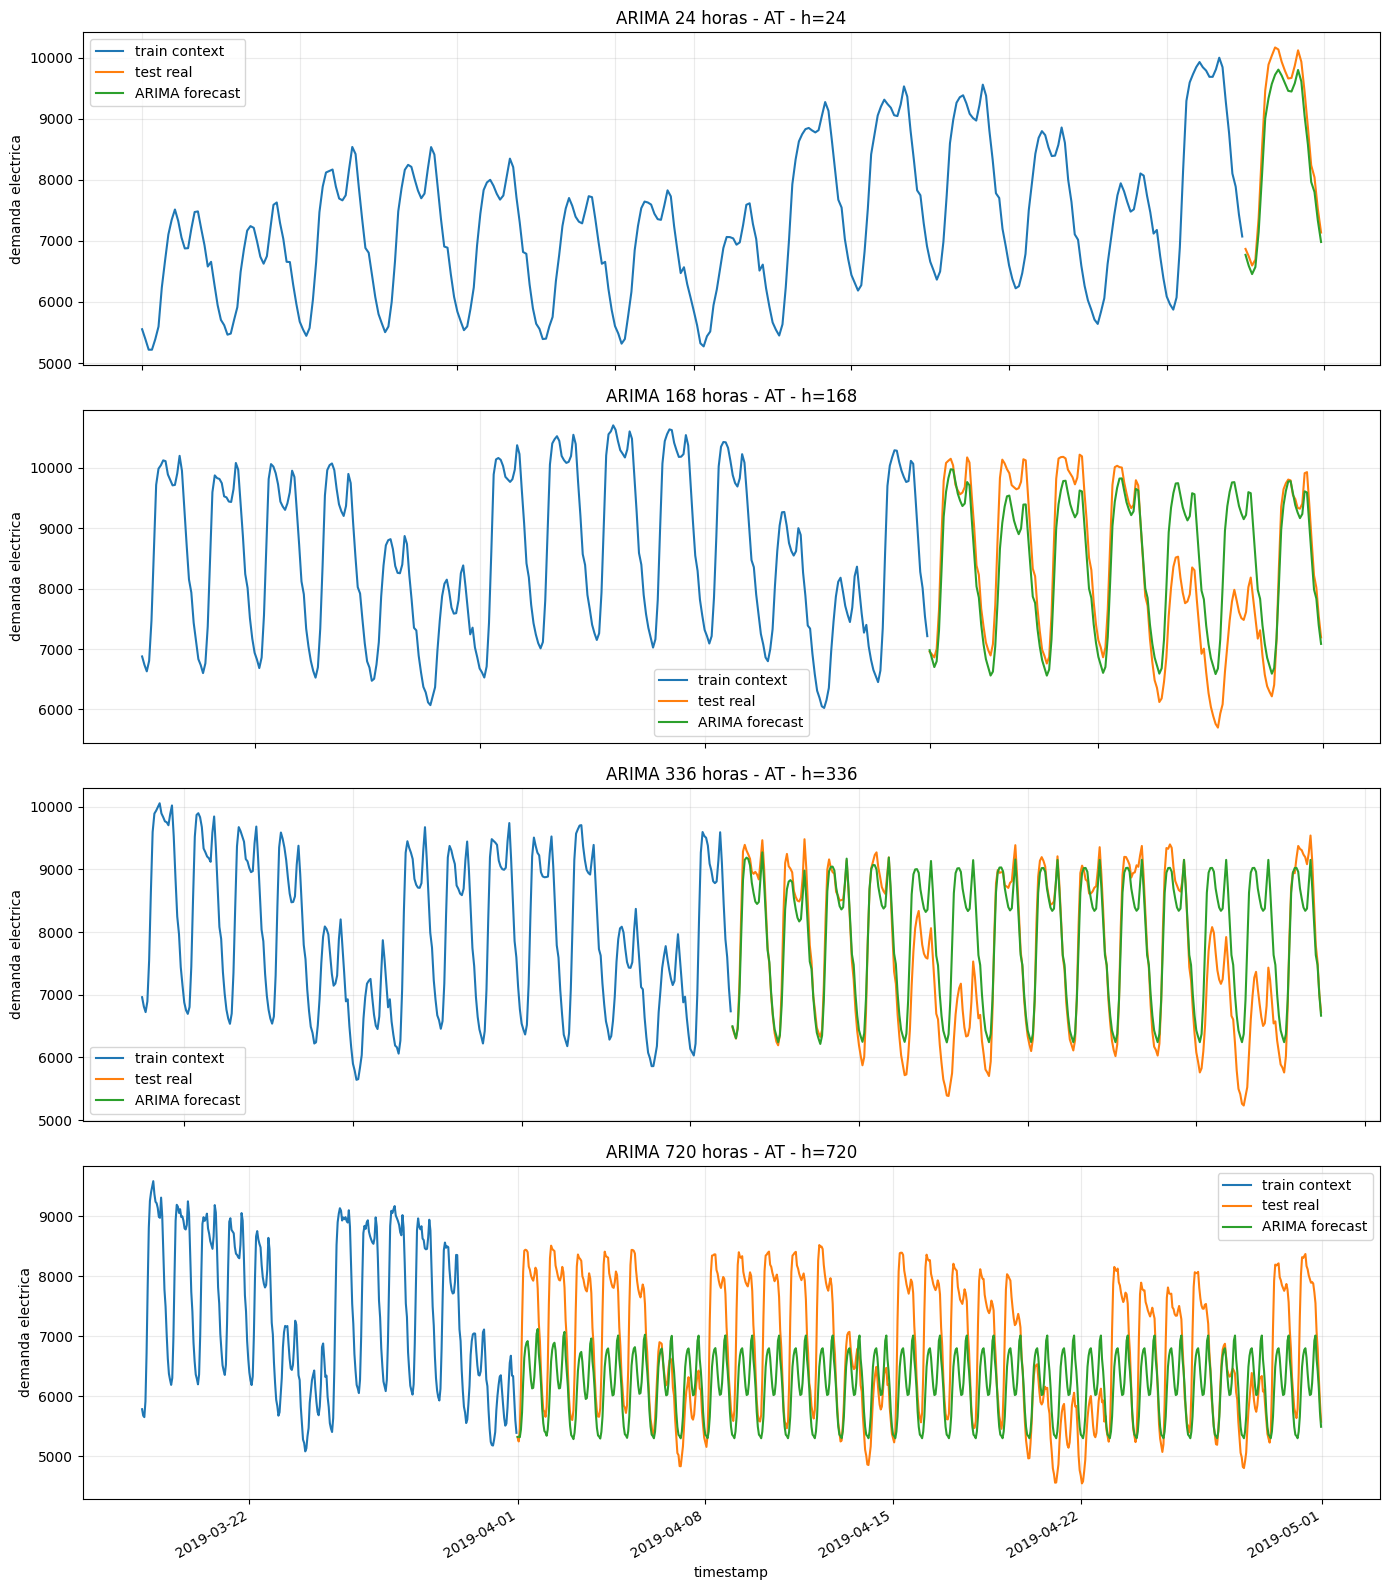

In [9]:
if forecasts:
    fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 4 * len(forecasts)), squeeze=False)
    for ax, experiment in zip(axes.ravel(), [item for item in EXPERIMENTS if item["name"] in forecasts]):
        forecast_df = forecasts[experiment["name"]]
        context_df = arima_train_contexts[experiment["name"]].tail(24 * 14)
        ax.plot(context_df["timestamp"], context_df["y"], label="train context")
        ax.plot(forecast_df["timestamp"], forecast_df["y"], label="test real")
        ax.plot(forecast_df["timestamp"], forecast_df["yhat"], label="ARIMA forecast")
        ax.set_title(f"ARIMA {experiment['label']} - {DATASET_NAME} - h={experiment['horizon']}")
        ax.set_xlabel("timestamp")
        ax.set_ylabel("demanda electrica")
        ax.legend()
        ax.grid(alpha=0.25)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
